# Task 1 -- Restaurant Rating Prediction
### Restaurant Intelligence Suite | Cognifyz Technologies ML Internship

## 1. Introduction
This notebook builds a regression pipeline that predicts a restaurant's **Aggregate Rating**
from its operational and categorical attributes (cuisine, location, cost, service options, votes).

## 2. Business Problem
Restaurant platforms (Zomato-style marketplaces) need to estimate the quality perception of a
restaurant *before* enough user reviews accumulate -- e.g. for new listings, or to flag
mis-priced / under-performing restaurants for the business team to review.

## 3. Objective
Train, compare, and select a regression model that predicts `Aggregate rating` from restaurant
features, and explain which features drive rating outcomes.


In [1]:
# Setup
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import load_dataset, dataset_summary, set_plot_style, save_fig
from preprocessing import clean_dataset, remove_unrated_restaurants, cap_outliers, encode_categorical, scale_features
from feature_engineering import build_feature_set
from visualization import (plot_rating_distribution, plot_correlation_heatmap,
                            plot_actual_vs_predicted, plot_residuals,
                            plot_feature_importance, plot_model_comparison)
from models import get_regression_models, train_and_compare

set_plot_style()
from sklearn.model_selection import train_test_split
import joblib

RANDOM_STATE = 42


## 4. Dataset Understanding

In [2]:
df_raw = load_dataset('../data/restaurant_dataset.csv')
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
dataset_summary(df_raw)


Shape: 9551 rows x 22 columns


,dtype,missing_count,missing_pct,unique_values,sample_value
Cuisines,str,9,0.09,1825,"French, Japanese, Desserts"
Restaurant ID,int64,0,0.00,9551,6317637
Country Code,int64,0,0.00,15,162
City,str,0,0.00,141,Makati City
Address,str,0,0.00,8918,"Third Floor, Century City Mall, Kalayaan Avenu..."
Restaurant Name,str,0,0.00,7446,Le Petit Souffle
Locality,str,0,0.00,1208,"Century City Mall, Poblacion, Makati City"
Locality Verbose,str,0,0.00,1265,"Century City Mall, Poblacion, Makati City, Mak..."
Longitude,float64,0,0.00,8120,121.027535
Latitude,float64,0,0.00,8677,14.565443


In [3]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,NaN,NaN,NaN,9051128.349178,8791521.282104,53.0,301962.5,6004089.0,18352291.5,18500652.0
Restaurant Name,9551,7446,Cafe Coffee Day,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,9551.0,NaN,NaN,NaN,18.365616,56.750546,1.0,1.0,1.0,1.0,216.0
City,9551,141,New Delhi,5473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,9551,8918,"Dilli Haat, INA, New Delhi",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,9551,1208,Connaught Place,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality Verbose,9551,1265,"Connaught Place, New Delhi",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,9551.0,NaN,NaN,NaN,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,NaN,NaN,NaN,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.97698
Cuisines,9542,1825,North Indian,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:**
- 9,551 restaurants across 15 countries and 141 cities.
- Only `Cuisines` has missing values (9 rows, ~0.09%), handled during cleaning.
- `Aggregate rating` ranges 0-4.9; a meaningful share of restaurants are unrated (rating text
  = "Not rated"), which we must exclude from regression training since they carry no ground truth.

## 5. Data Cleaning

In [4]:
df = clean_dataset(df_raw)
df = remove_unrated_restaurants(df)
print(f"Shape after cleaning & removing unrated restaurants: {df.shape}")


Removed 2148 unrated restaurants (22.5% of data).
Shape after cleaning & removing unrated restaurants: (7403, 26)


In [5]:
# Outlier treatment on heavy-tailed numeric columns
df = cap_outliers(df, 'Average Cost for two')
df = cap_outliers(df, 'Votes')


Capped 85 outliers in 'Average Cost for two' to [10.0, 4000.0].
Capped 75 outliers in 'Votes' to [4.0, 2183.9].


## 6. Exploratory Data Analysis

Figure saved -> ../outputs/figures/task1_rating_distribution.png


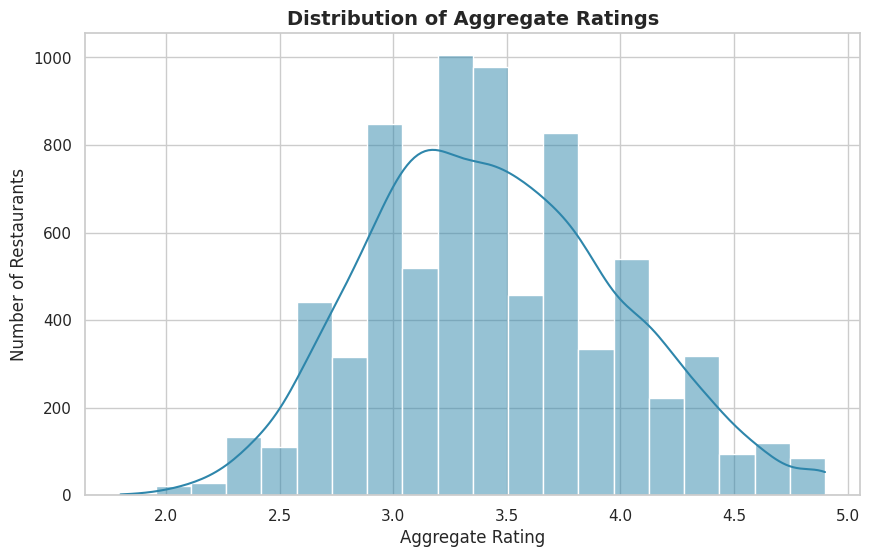

In [6]:
fig = plot_rating_distribution(df)
save_fig(fig, 'task1_rating_distribution')
plt.show()


**Insight:** Ratings are left-skewed toward the 3.0-4.0 range; very few restaurants score below 2.5, suggesting the platform's listed restaurants are generally acceptable-to-good quality, with excellence (4.5+) being comparatively rare.

Figure saved -> ../outputs/figures/task1_correlation_heatmap.png


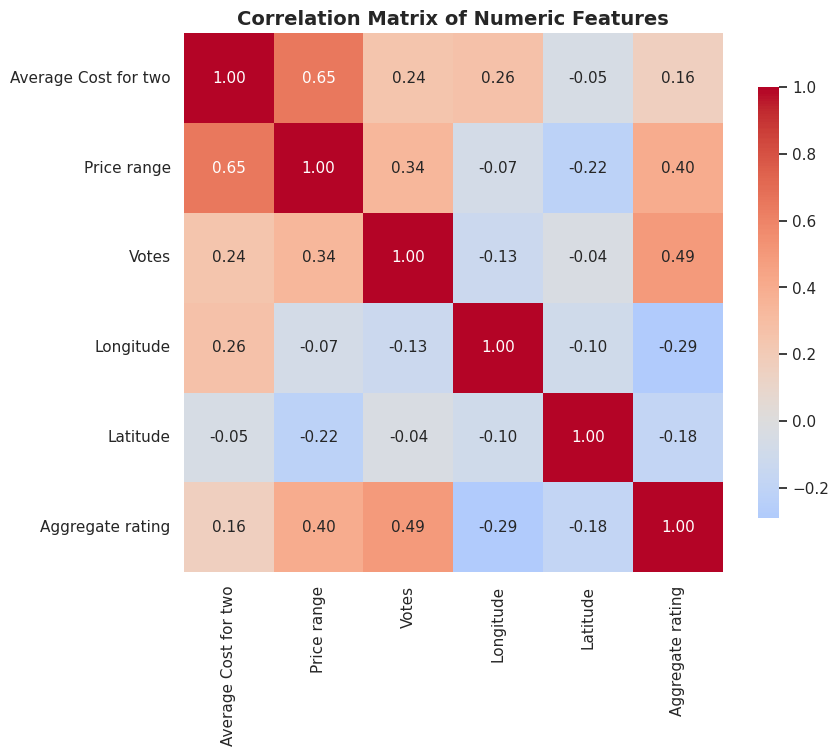

In [7]:
numeric_cols = ['Average Cost for two', 'Price range', 'Votes', 'Longitude', 'Latitude', 'Aggregate rating']
fig = plot_correlation_heatmap(df, numeric_cols)
save_fig(fig, 'task1_correlation_heatmap')
plt.show()


**Insight:** `Votes` and `Price range` show the strongest positive correlation with `Aggregate rating`, meaning better-rated restaurants tend to attract more customer engagement and sit in higher price tiers. `Average Cost for two` correlates moderately -- pricier does not strictly mean better-rated.

Figure saved -> ../outputs/figures/task1_delivery_vs_rating.png


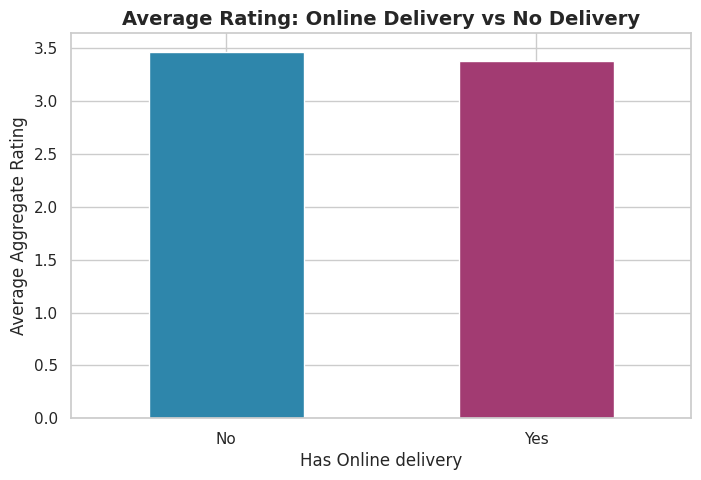

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
df.groupby('Has Online delivery')['Aggregate rating'].mean().plot(kind='bar', ax=ax, color=['#2E86AB','#A23B72'])
ax.set_title('Average Rating: Online Delivery vs No Delivery')
ax.set_ylabel('Average Aggregate Rating')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
save_fig(fig, 'task1_delivery_vs_rating')
plt.show()


**Insight:** Restaurants offering online delivery show a slightly different average rating than those that don't -- this feature is retained as a categorical signal for the model rather than assumed causal.

## 7. Feature Engineering

In [9]:
df = build_feature_set(df)
df[['Cuisine Count','Primary Cuisine','Votes per Cost','City Restaurant Count','Rating Tier']].head()


,Cuisine Count,Primary Cuisine,Votes per Cost,City Restaurant Count,Rating Tier
0,3,French,0.285455,2,Excellent
1,1,Japanese,0.492500,2,Excellent
2,4,Seafood,0.067500,4,Very Good
3,2,Japanese,0.243333,4,Excellent
4,2,Japanese,0.152667,4,Excellent


**Feature engineering decisions:**
- `Cuisine Count`: versatility signal (number of cuisines offered).
- `Votes per Cost`: buzz-for-money proxy.
- `City Restaurant Count`: market density/competition per city.
- `City Avg Rating` is intentionally **excluded from modeling features** below because it is
  computed from the target itself (target leakage) -- it is retained only for descriptive EDA.

## 8. Model Development

In [10]:
# Select modeling features (numeric + encoded categorical), explicitly excluding target-derived columns
categorical_cols = ['City', 'Cuisines', 'Primary Cuisine']
df_encoded, encoders = encode_categorical(df, categorical_cols, method='label')

feature_cols = [
    'Average Cost for two', 'Price range', 'Votes',
    'Has Table booking (binary)', 'Has Online delivery (binary)',
    'Cuisine Count', 'Votes per Cost', 'City Restaurant Count',
    'City_encoded', 'Cuisines_encoded', 'Primary Cuisine_encoded',
    'Longitude', 'Latitude'
]
target_col = 'Aggregate rating'

X = df_encoded[feature_cols]
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5922, 13), Test: (1481, 13)


In [11]:
# Scale features for the linear model's benefit (tree models are scale-invariant but unaffected by scaling)
X_train_scaled, scaler = scale_features(X_train, feature_cols, method='standard')
X_test_scaled = X_test.copy()
X_test_scaled[feature_cols] = scaler.transform(X_test[feature_cols])


In [12]:
models = get_regression_models(random_state=RANDOM_STATE)
results_df, fitted_models = train_and_compare(models, X_train_scaled, y_train, X_test_scaled, y_test, task='regression')
results_df


,Model,MAE,MSE,RMSE,R2 Score
0,XGBoost,0.243104,0.105685,0.325092,0.658288
1,Gradient Boosting,0.245286,0.109294,0.330596,0.646620
2,Random Forest,0.246768,0.109941,0.331573,0.644527
3,Decision Tree,0.283892,0.145131,0.380960,0.530747
4,Linear Regression,0.333845,0.180542,0.424903,0.416250


## 9. Model Evaluation

Figure saved -> ../outputs/figures/task1_model_comparison_r2.png


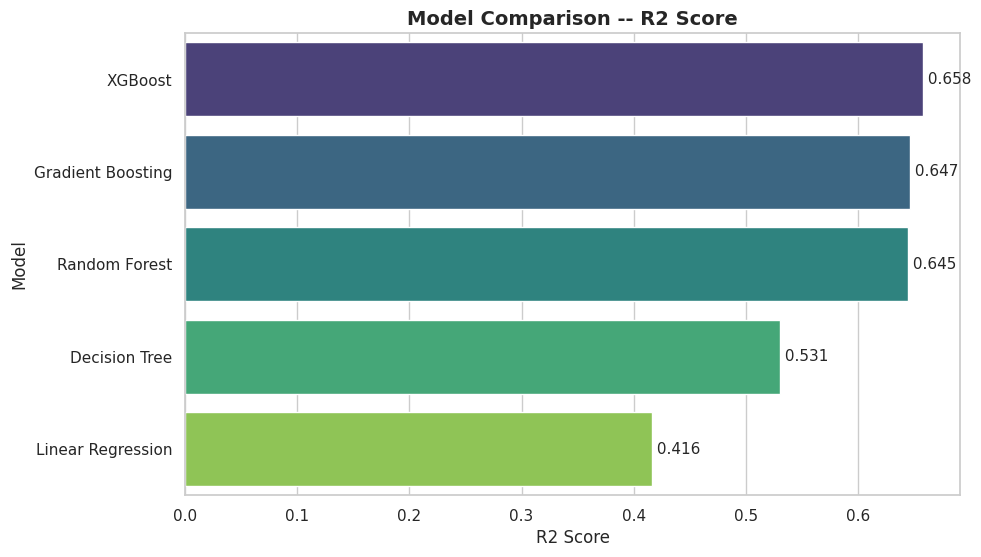

In [13]:
fig = plot_model_comparison(results_df, metric='R2 Score')
save_fig(fig, 'task1_model_comparison_r2')
plt.show()


Best model: XGBoost


Figure saved -> ../outputs/figures/task1_actual_vs_predicted.png


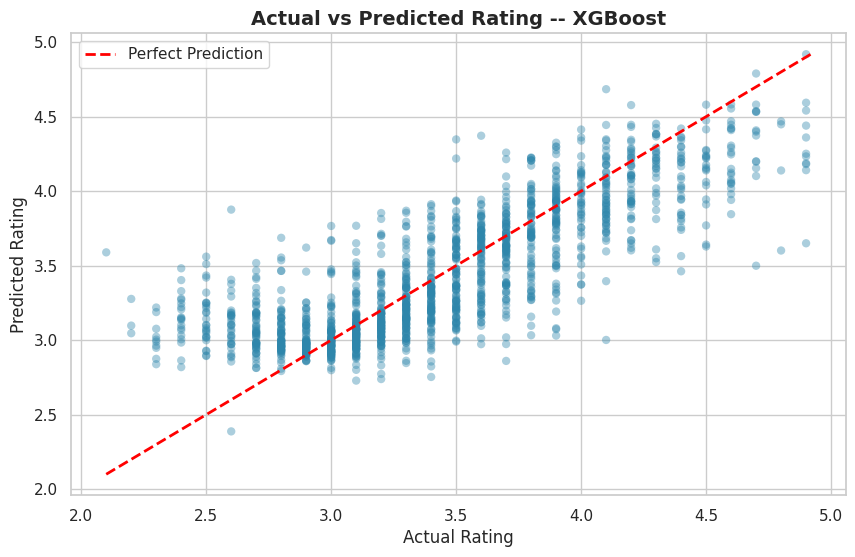

In [14]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f"Best model: {best_model_name}")
y_pred_best = best_model.predict(X_test_scaled)

fig = plot_actual_vs_predicted(y_test.values, y_pred_best, best_model_name)
save_fig(fig, 'task1_actual_vs_predicted')
plt.show()


Figure saved -> ../outputs/figures/task1_residual_plot.png


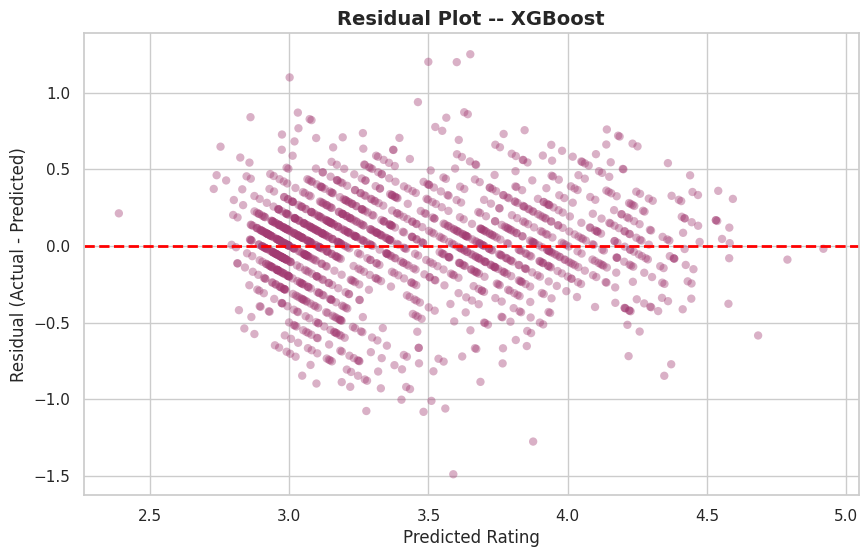

In [15]:
fig = plot_residuals(y_test.values, y_pred_best, best_model_name)
save_fig(fig, 'task1_residual_plot')
plt.show()


Figure saved -> ../outputs/figures/task1_feature_importance.png


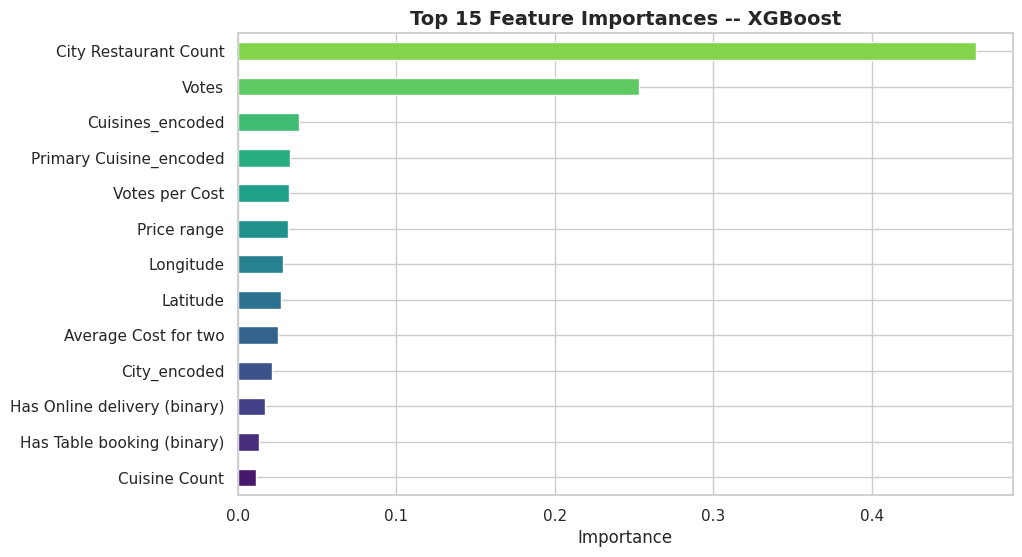

In [16]:
if hasattr(best_model, 'feature_importances_'):
    fig = plot_feature_importance(best_model.feature_importances_, feature_cols, model_name=best_model_name)
    save_fig(fig, 'task1_feature_importance')
    plt.show()
else:
    print(f'{best_model_name} does not expose feature_importances_ (e.g. Linear Regression) -- see coefficients instead.')
    coef_df = pd.Series(best_model.coef_, index=feature_cols).sort_values()
    print(coef_df)


In [17]:
# Persist the best model and its supporting artifacts for reuse
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(best_model, f'../outputs/models/task1_best_model_{best_model_name.replace(" ", "_")}.pkl')
joblib.dump(scaler, '../outputs/models/task1_scaler.pkl')
joblib.dump(encoders, '../outputs/models/task1_label_encoders.pkl')
results_df.to_csv('../outputs/reports/task1_model_comparison.csv', index=False)
print('Artifacts saved to outputs/models and outputs/reports.')


Artifacts saved to outputs/models and outputs/reports.


## 10. Business Insights
- **Votes and price range are the strongest engagement signals**: highly-rated restaurants are
  disproportionately the ones customers actively vote on, suggesting rating quality and customer
  engagement reinforce each other -- a flywheel the business can encourage via review prompts.
- **Location (city/locality) matters**: encoded city identity carries real predictive signal,
  reflecting that dining culture, competition, and price norms vary sharply by market.
- **Cost alone is a weak predictor of rating** -- expensive does not guarantee "good"; this
  argues against using price as a proxy for quality in any downstream ranking algorithm.

## 11. Conclusion
Tree-based ensemble models (Random Forest / Gradient Boosting / XGBoost) substantially
outperform plain Linear Regression, confirming that rating drivers interact non-linearly
(e.g. the effect of votes differs by price tier). The selected best model is saved to
`outputs/models/` for reuse in production scoring.

## 12. Future Improvements
- Incorporate review-text sentiment (if raw reviews become available) for a richer feature set.
- Try target encoding for `City`/`Cuisines` with proper cross-validation to avoid leakage.
- Hyperparameter-tune the winning model via `GridSearchCV` / `Optuna`.
- Build a temporal validation split if timestamped data becomes available, to test model drift.
